In [2]:
from typing_extensions import Literal
from langchain_core.tools import tool
from langchain_groq import ChatGroq
from langgraph.graph import MessagesState, StateGraph, START, END
from langgraph.types import Command
from dotenv import load_dotenv
from IPython.display import Image, display
from langchain_core.messages import BaseMessage, HumanMessage
from langgraph.prebuilt import create_react_agent
from typing import Annotated
from langchain_experimental.utilities import PythonREPL
from langchain_community.tools import DuckDuckGoSearchRun

In [25]:
load_dotenv()
groq_model = ChatGroq(model= "llama-3.1-8b-instant")

In [26]:
groq_model.invoke("Hi")

AIMessage(content="It's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 36, 'total_tokens': 59, 'completion_time': 0.023212472, 'prompt_time': 0.002162985, 'queue_time': 0.158997543, 'total_time': 0.025375457}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_7ccc667439', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e91f2-c9d9-7370-bff6-482276261e3f-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 36, 'output_tokens': 23, 'total_tokens': 59})

In [3]:
search_tool = DuckDuckGoSearchRun()

In [4]:
search_tool.invoke("What is GDP of India?")

"Gross domestic product (GDP) is the market value of all final goods and services from a nation in a given year. [2] Countries are sorted by nominal GDP estimates from financial and statistical institutions, which are calculated at market or government official exchange rates. GDP of India at constant (2011-12) prices and current prices in indian rupees. Estimates by world bank since 1960 in nominal terms and since 1990 in ppp terms at current and constant prices. Projections by IMF. Discover how India calculates GDP using factor cost and expenditure approaches and gain insight into its economic health and leading sectors. India's GDP for FY 2025-26 — nominal GDP ₹357 lakh crore (~$3.96 trillion), real growth rate 7.4%, India as 4th largest economy overtaking Japan, sector contributions, PPP comparison, and UPSC-relevant analysis. India slipped to sixth in IMF GDP rankings due to rupee depreciation and base revision, even as the economy continued strong growth and is expected to regain

In [5]:
repl = PythonREPL()

In [6]:
code = """"
x = 5
y = x*2
print(y)
"""

In [8]:
repl.run(code)

Python REPL can execute arbitrary code. Use with caution.


'SyntaxError(\'unterminated string literal (detected at line 1)\', (\'<string>\', 1, 1, \'"\', 1, 1))'

In [9]:
@tool
def python_repl_tool(
    code: Annotated[str, "The python code to execute to generate your chart."],
):
    """Use this to execute python code. If you want to see the output of a value,
    you should print it out with `print(...)`. This is visible to the user.
    """

    try:
        result = repl.run(code)
    except BaseException as e:
        return f"Failed to execute. Error: {repr(e)}"

    result_str = (
        f"Successfully executed:\n```python\n{code}\n```\n\nStdout: {result}"
    )

    return (
        result_str
        + "\n\nIf you have completed all tasks, respond with FINAL ANSWER."
    )

In [10]:
def make_system_prompt(instruction: str) -> str:
    return (
        "You are a helpful AI assistant, collaborating with other assistants.\n"
        " Use the provided tools to progress towards answering the question.\n"
        " If you are unable to fully answer, that's OK, another assistant with different tools "
        " will help where you left off. Execute what you can to make progress.\n"
        " If you or any of the other assistants have the final answer or deliverable,"
        " prefix your response with FINAL ANSWER so the team knows to stop.\n"
        f"\n{instruction}"
    )

In [11]:
def get_next_node(last_message: BaseMessage, goto:str):
    if "FINAL ANSWER" in last_message.content:
        # Any agent decided the work is done
        return END
    return goto


In [34]:
research_agent = create_react_agent(
    groq_model,
    tools = [search_tool],
    prompt = make_system_prompt(
        "You can only do research. You are working with a chart generator colleague."
    ),
)

C:\Users\LOQ\AppData\Local\Temp\ipykernel_15332\1117582359.py:1: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  research_agent = create_react_agent(


In [35]:
chart_agent = create_react_agent(
    groq_model,
    tools = [python_repl_tool],
    prompt = make_system_prompt(
        "You can only generate charts. You are working with a researcher colleague."
    ),
)

C:\Users\LOQ\AppData\Local\Temp\ipykernel_15332\1400268643.py:1: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  chart_agent = create_react_agent(


In [36]:
def research_node(state: MessagesState) -> Command[Literal["chart_generator", END]]:
    result = research_agent.invoke(state)

    goto = get_next_node(result["messages"][-1], "chart_generator")

    result["messages"][-1] = HumanMessage(
        content=result["messages"][-1].content,
        name="researcher"
    )

    return Command(
        update={
            # share internal message history of researcher agent with other agents
            "messages": result["messages"],
        },
        goto=goto,
    )

In [29]:
def chart_node(state: MessagesState) -> Command[Literal["researcher", END]]:
    result = chart_agent.invoke(state)

    goto = get_next_node(result["messages"][-1], "researcher")

    result["messages"][-1] = HumanMessage(
        content=result["messages"][-1].content,
        name="chart_generator"
    )

    return Command(
        update={
            # share internal message history of chart agent with other agents
            "messages": result["messages"],
        },
        goto=goto,
    )

In [37]:
from langgraph.graph import StateGraph, START

workflow = StateGraph(MessagesState)
workflow.add_node("researcher", research_node)
workflow.add_node("chart_generator", chart_node)

workflow.add_edge(START, "researcher")
app = workflow.compile()

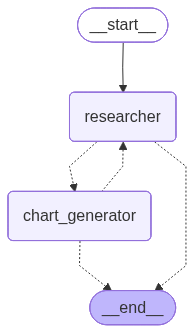

In [39]:
display(Image(app.get_graph().draw_mermaid_png()))

In [40]:
app.invoke({"messages": [HumanMessage(content="get the UK's GDP over the past 3 years, then make a line chart of it. Once you make the chart, finish.")]})

BadRequestError: Error code: 400 - {'error': {'message': "tool call validation failed: attempted to call tool 'bradley_taylor_chart_generator' which was not in request.tools", 'type': 'invalid_request_error', 'code': 'tool_use_failed', 'failed_generation': '<function=bradley_taylor_chart_generator> {"function": "line_chart", "x_axis_title": "Year", "y_axis_title": "GDP", "title": "UK GDP Over Past 3 Years"} </function>\n\n'}}